In [83]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

E:\IIT JAMMU\Projects\cold-start-article-recommender


In [82]:
# Cold Start Article Recommendation System

## Phase 3 - Exploratory Data Analysis

### 1. Import Libraries

### 2. Load Dataset

### 3. Dataset Overview

### 4. Missing Value Analysis

### 5. Duplicate Analysis

### 6. Category Analysis

### 7. Text Statistics

### 8. Conclusions

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better plot appearance
plt.style.use("ggplot")

In [3]:
df = pd.read_json(
    "../data/raw/News_Category_Dataset_v3.json",
    lines=True
)

In [4]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [5]:
df.shape

(209527, 6)

In [6]:
df.columns

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  str           
 1   headline           209527 non-null  str           
 2   category           209527 non-null  str           
 3   short_description  209527 non-null  str           
 4   authors            209527 non-null  str           
 5   date               209527 non-null  datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 71.2 MB


In [8]:
df.describe(include="all")

,link,headline,category,short_description,authors,date
count,209527,209527,209527,209527,209527,209527
unique,209486,207996,42,187022,29169,NaN
top,https://www.huffingtonpost.comhttp://www.polit...,Sunday Roundup,POLITICS,,,NaN
freq,2,90,35602,19712,37418,NaN
mean,NaN,NaN,NaN,NaN,NaN,2015-04-30 00:44:14.344308
min,NaN,NaN,NaN,NaN,NaN,2012-01-28 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,2013-08-10 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,2015-03-16 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,2016-11-01 00:00:00
max,NaN,NaN,NaN,NaN,NaN,2022-09-23 00:00:00


In [9]:
# Count missing values
df.isnull().sum()

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(13)

In [11]:
df["category"].nunique()

42

In [12]:
sorted(df["category"].unique())

['ARTS',
 'ARTS & CULTURE',
 'BLACK VOICES',
 'BUSINESS',
 'COLLEGE',
 'COMEDY',
 'CRIME',
 'CULTURE & ARTS',
 'DIVORCE',
 'EDUCATION',
 'ENTERTAINMENT',
 'ENVIRONMENT',
 'FIFTY',
 'FOOD & DRINK',
 'GOOD NEWS',
 'GREEN',
 'HEALTHY LIVING',
 'HOME & LIVING',
 'IMPACT',
 'LATINO VOICES',
 'MEDIA',
 'MONEY',
 'PARENTING',
 'PARENTS',
 'POLITICS',
 'QUEER VOICES',
 'RELIGION',
 'SCIENCE',
 'SPORTS',
 'STYLE',
 'STYLE & BEAUTY',
 'TASTE',
 'TECH',
 'THE WORLDPOST',
 'TRAVEL',
 'U.S. NEWS',
 'WEDDINGS',
 'WEIRD NEWS',
 'WELLNESS',
 'WOMEN',
 'WORLD NEWS',
 'WORLDPOST']

In [13]:
df["category"].value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [14]:
df["text"] = (
    df["headline"].fillna("")
    + " "
    + df["short_description"].fillna("")
)

In [15]:
df[["headline", "short_description", "text"]].head()

,headline,short_description,text
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Woman Who Called Cops On Black Bird-Watcher Lo...


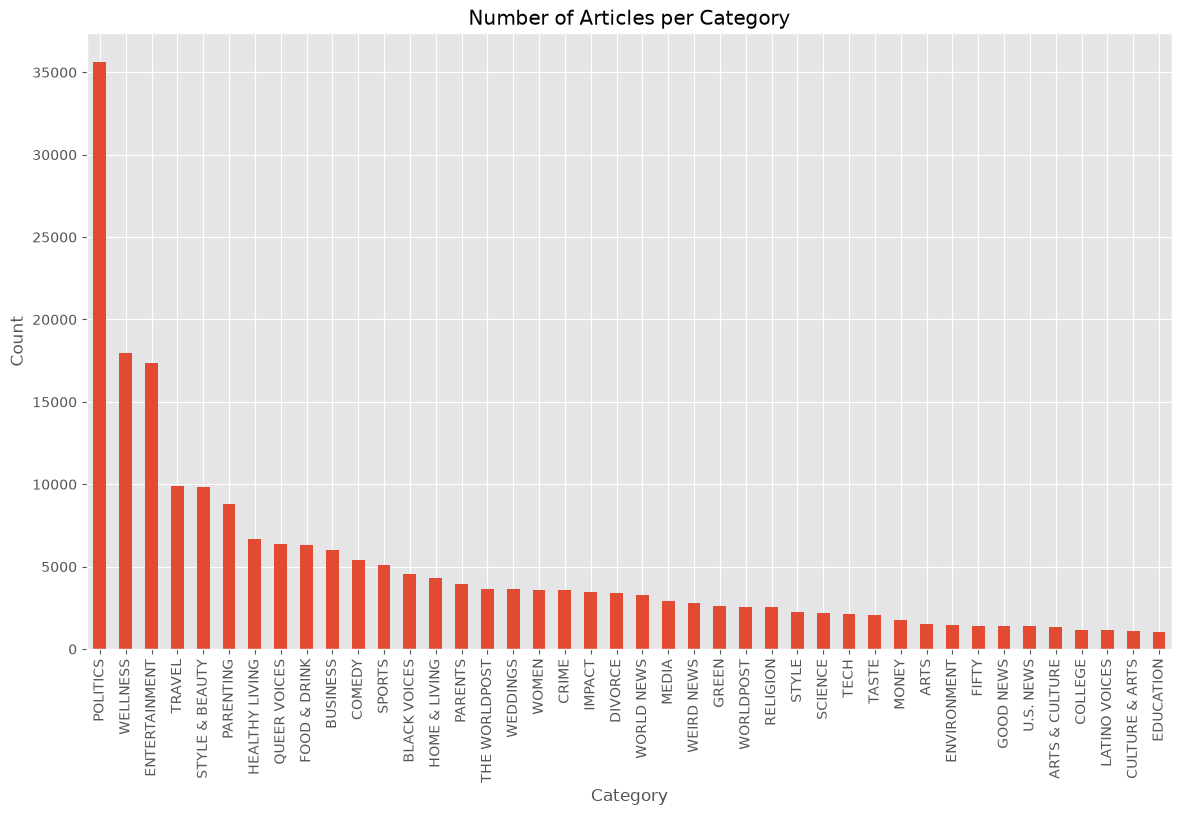

In [23]:
plt.figure(figsize=(14, 8))

df["category"].value_counts().plot(kind="bar")

plt.title("Number of Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

### Observation

#The dataset contains 42 news categories with an imbalanced distribution.
#Politics has the largest number of articles, while several niche categories contain fewer records. This imbalance is acceptable because the recommendation system compares article content rather than predicting category labels.

In [17]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

In [18]:
df["word_count"].describe()

### Observation

#Most articles are relatively short, with an average length of approximately 34 words.
#The short text length makes the dataset well suited for TF-IDF vectorization because feature extraction will be computationally efficient.

count    209527.000000
mean         29.269770
std          13.803927
min           0.000000
25%          20.000000
50%          28.000000
75%          35.000000
max         245.000000
Name: word_count, dtype: float64

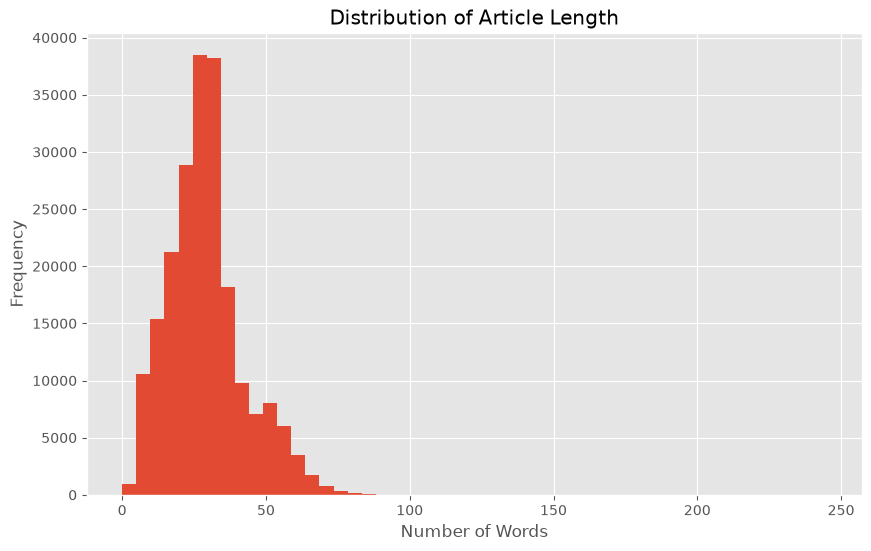

In [25]:
plt.figure(figsize=(10,6))

plt.hist(df["word_count"], bins=50)

plt.title("Distribution of Article Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

### Observation

#The histogram shows a right-skewed distribution.
#Most articles contain between 20 and 50 words, while only a small number contain significantly more words.
#No abnormal outliers are observed that would negatively affect preprocessing.

In [26]:
from collections import Counter

all_words = " ".join(df["text"]).lower().split()

word_counts = Counter(all_words)

word_counts.most_common(20)

### Observation

#Common English stop words dominate the vocabulary.
#These words carry little semantic meaning and will be removed during the text preprocessing stage to improve feature quality.

[('the', 269874),
 ('to', 169729),
 ('a', 136467),
 ('of', 132671),
 ('and', 121163),
 ('in', 99044),
 ('is', 66821),
 ('for', 66231),
 ('that', 48972),
 ('on', 48681),
 ('you', 41917),
 ('with', 41531),
 ('i', 35284),
 ('are', 34391),
 ('it', 31041),
 ('your', 28788),
 ('this', 28763),
 ('be', 28722),
 ('as', 27014),
 ('at', 26625)]

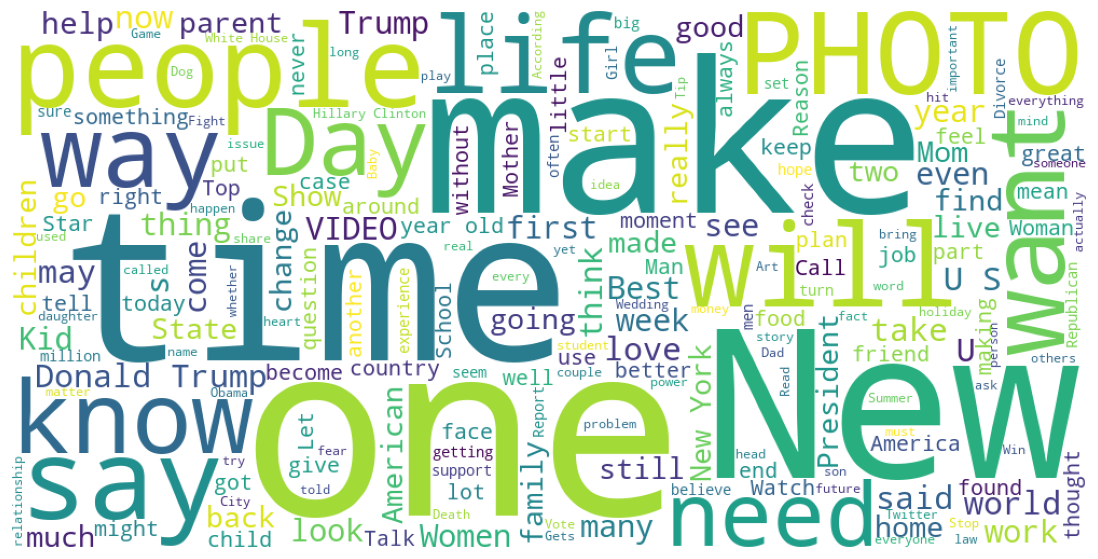

In [27]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(df["text"]))

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

### Observation

#The Word Cloud highlights the most frequently occurring terms in the dataset.
#Many common English words appear prominently because preprocessing has not yet been performed.
#A cleaner and more meaningful visualization will be generated after text cleaning.

In [31]:
import nltk

nltk.download("stopwords", download_dir="./nltk_data")
nltk.download("punkt", download_dir="./nltk_data")
nltk.download("wordnet", download_dir="./nltk_data")
nltk.download("omw-1.4", download_dir="./nltk_data")

[nltk_data] Downloading package stopwords to ./nltk_data...
[nltk_data] Error downloading 'stopwords' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/corpora/stopwords.zip>:   Security
[nltk_data]     Violation [Downloader._download_package]: Unauthorized
[nltk_data]     path E:\IIT JAMMU\Projects\cold-start-article-recommen
[nltk_data]     der\notebooks\nltk_data\corpora\stopwords.zip.tmp
[nltk_data] Downloading package punkt to ./nltk_data...
[nltk_data] Error downloading 'punkt' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/tokenizers/punkt.zip>:   Security
[nltk_data]     Violation [Downloader._download_package]: Unauthorized
[nltk_data]     path E:\IIT JAMMU\Projects\cold-start-article-recommen
[nltk_data]     der\notebooks\nltk_data\tokenizers\punkt.zip.tmp
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data] Error downloading 'wordnet' from
[nltk

False

In [32]:
nltk.download("stopwords", download_dir="./nltk_data")
nltk.download("punkt", download_dir="./nltk_data")
nltk.download("wordnet", download_dir="./nltk_data")
nltk.download("omw-1.4", download_dir="./nltk_data")

[nltk_data] Downloading package stopwords to ./nltk_data...
[nltk_data] Error downloading 'stopwords' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/corpora/stopwords.zip>:   Security
[nltk_data]     Violation [Downloader._download_package]: Unauthorized
[nltk_data]     path E:\IIT JAMMU\Projects\cold-start-article-recommen
[nltk_data]     der\notebooks\nltk_data\corpora\stopwords.zip.tmp
[nltk_data] Downloading package punkt to ./nltk_data...
[nltk_data] Error downloading 'punkt' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/tokenizers/punkt.zip>:   Security
[nltk_data]     Violation [Downloader._download_package]: Unauthorized
[nltk_data]     path E:\IIT JAMMU\Projects\cold-start-article-recommen
[nltk_data]     der\notebooks\nltk_data\tokenizers\punkt.zip.tmp
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data] Error downloading 'wordnet' from
[nltk

False

In [33]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Number of stop words:", len(stop_words))
print("Example stop words:", list(stop_words)[:10])
print("Lemmatizer created successfully!")

Number of stop words: 198
Example stop words: ['again', 'between', 'both', "don't", 'our', "won't", 'then', 'll', 'you', 'weren']
Lemmatizer created successfully!


In [34]:
sample_text = "OpenAI Launches GPT-6! Read more at https://openai.com/blog <br> It's AMAZING!!!"

print("Original:")
print(sample_text)

lower_text = sample_text.lower()

print("\nAfter Lowercase:")
print(lower_text)

Original:
OpenAI Launches GPT-6! Read more at https://openai.com/blog <br> It's AMAZING!!!

After Lowercase:
openai launches gpt-6! read more at https://openai.com/blog <br> it's amazing!!!


In [35]:
import re

html_removed = re.sub(r"<.*?>", "", lower_text)

print(html_removed)

openai launches gpt-6! read more at https://openai.com/blog  it's amazing!!!


In [36]:
url_removed = re.sub(r"http\S+|www\S+", "", html_removed)

print(url_removed)

openai launches gpt-6! read more at   it's amazing!!!


In [37]:
import string

punctuation_removed = url_removed.translate(
    str.maketrans("", "", string.punctuation)
)

print(punctuation_removed)

openai launches gpt6 read more at   its amazing


In [38]:
numbers_removed = re.sub(r"\d+", "", punctuation_removed)

print(numbers_removed)

openai launches gpt read more at   its amazing


In [40]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\snehi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [41]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(numbers_removed)
print(tokens)

['openai', 'launches', 'gpt', 'read', 'more', 'at', 'its', 'amazing']


In [42]:
filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]

print(filtered_tokens)

['openai', 'launches', 'gpt', 'read', 'amazing']


In [43]:
lemmatized_tokens = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

print(lemmatized_tokens)

['openai', 'launch', 'gpt', 'read', 'amazing']


In [44]:
def preprocess_text(text):
    """
    Clean and preprocess article text for TF-IDF vectorization.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join tokens back into a string
    return " ".join(tokens)

In [45]:
clean_text = preprocess_text(sample_text)

print(clean_text)

openai launch gpt read amazing


In [47]:
sample_df = df.head().copy()

sample_df["clean_text"] = sample_df["text"].apply(preprocess_text)

sample_df[["text", "clean_text"]]

,text,clean_text
0,Over 4 Million Americans Roll Up Sleeves For O...,million american roll sleeve omicrontargeted c...
1,"American Airlines Flyer Charged, Banned For Li...",american airline flyer charged banned life pun...
2,23 Of The Funniest Tweets About Cats And Dogs ...,funniest tweet cat dog week sept dog dont unde...
3,The Funniest Tweets From Parents This Week (Se...,funniest tweet parent week sept accidentally p...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,woman called cop black birdwatcher loses lawsu...


In [48]:
df.shape


(209527, 9)

In [49]:
df.head()

,link,headline,category,short_description,authors,date,text,word_count,clean_text
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...,40,million american roll sleeve omicrontargeted c...
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li...",41,american airline flyer charged banned life pun...
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...,25,funniest tweet cat dog week sept dog dont unde...
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...,34,funniest tweet parent week sept accidentally p...
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...,36,woman called cop black birdwatcher loses lawsu...


In [50]:
from tqdm import tqdm

tqdm.pandas()

df["clean_text"] = df["text"].progress_apply(preprocess_text)

100%|██████████| 209527/209527 [01:30<00:00, 2314.91it/s]


In [51]:
df[["text", "clean_text"]].head()

,text,clean_text
0,Over 4 Million Americans Roll Up Sleeves For O...,million american roll sleeve omicrontargeted c...
1,"American Airlines Flyer Charged, Banned For Li...",american airline flyer charged banned life pun...
2,23 Of The Funniest Tweets About Cats And Dogs ...,funniest tweet cat dog week sept dog dont unde...
3,The Funniest Tweets From Parents This Week (Se...,funniest tweet parent week sept accidentally p...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,woman called cop black birdwatcher loses lawsu...


In [52]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/clean_articles.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the vectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Convert text into TF-IDF features
tfidf_matrix = vectorizer.fit_transform(df["clean_text"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (209527, 10000)


In [54]:
print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 10000


In [55]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:30])

['aaron' 'ab' 'abandon' 'abandoned' 'abbey' 'abc' 'abc news' 'ability'
 'able' 'aboard' 'abortion' 'abound' 'abraham' 'abrams' 'abroad' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'abundance' 'abuse' 'abused'
 'abuser' 'abusive' 'aca' 'academic' 'academy' 'academy award' 'accent']


In [56]:
first_article_vector = tfidf_matrix[0]

print(first_article_vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 5542)	0.3782279110526677
  (0, 263)	0.16650186247659282
  (0, 7506)	0.2557143499146189
  (0, 8100)	0.32690262225528377
  (0, 1885)	0.25403068986111055
  (0, 3860)	0.17234706202304725
  (0, 2955)	0.22043805414846193
  (0, 7609)	0.1536702841585461
  (0, 2617)	0.2192273276507548
  (0, 6721)	0.297991966721169
  (0, 2199)	0.24387554532258424
  (0, 5362)	0.26203841682284085
  (0, 5854)	0.12529783516044782
  (0, 6142)	0.28456163226361897
  (0, 3035)	0.20639935986828759
  (0, 5543)	0.2936804693036098


In [57]:
dense_vector = tfidf_matrix[0].toarray()

print(dense_vector.shape)

(1, 10000)


In [58]:
import numpy as np

print("Non-zero features:", np.count_nonzero(dense_vector))

Non-zero features: 16


In [60]:
from sklearn.metrics.pairwise import cosine_similarity

In [61]:
def recommend_articles(article_index: int, top_n: int = 5):
    """
    Recommend the top N most similar articles.

    Parameters:
        article_index (int): Index of the selected article.
        top_n (int): Number of recommendations.

    Returns:
        pandas.DataFrame
    """

    # Compute similarity between ONE article and ALL articles
    similarity_scores = cosine_similarity(
        tfidf_matrix[article_index],
        tfidf_matrix
    ).flatten()

    # Sort by similarity score (highest first)
    similar_indices = similarity_scores.argsort()[::-1]

    # Remove the selected article itself
    similar_indices = similar_indices[similar_indices != article_index]

    # Keep only the top N
    top_indices = similar_indices[:top_n]

    # Create the result table
    recommendations = df.loc[
        top_indices,
        ["headline", "category", "clean_text"]
    ].copy()

    recommendations["similarity_score"] = similarity_scores[top_indices]

    return recommendations

In [62]:
recommend_articles(0)

,headline,category,clean_text,similarity_score
115339,The $11-Million Manhunt,CRIME,million manhunt,0.378228
46053,More Than 10 Million Americans Now Identify As...,QUEER VOICES,million american identify lgbt 🦄 🦄 🦄,0.347592
1091,CDC Estimates More Than 140 Million Americans ...,U.S. NEWS,cdc estimate million american covid far nearly...,0.320732
36153,America’s Health Is In The Hands Of GOP Frat Boys,POLITICS,america ’ health hand gop frat boy health care...,0.315982
35272,The Global Cyberattack And The Need To Revisit...,TECH,global cyberattack need revisit health care cy...,0.305316


In [63]:
def search_articles(keyword: str, top_n: int = 10):
    """
    Search articles whose headlines contain the keyword.
    """

    results = df[
        df["headline"].str.contains(
            keyword,
            case=False,
            na=False
        )
    ]

    return results[["headline", "category"]].head(top_n)

In [64]:
search_articles("covid")

,headline,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
206,CDC Director To Overhaul Agency With COVID Sho...,POLITICS
238,"CDC Drops Some Quarantine, Screening Recommend...",U.S. NEWS
335,"Biden Improves 'Significantly,' Throat Still S...",POLITICS
470,Deborah Birx Says Trump Officials Made Her Cha...,U.S. NEWS
498,CDC Recommends COVID-19 Shots For Children Und...,U.S. NEWS
512,There Are Millions Of People Who Can't Just 'M...,WELLNESS
535,Jeff Bridges Shares Powerful Lessons From Canc...,U.S. NEWS
541,The Most Common Questions About The Novavax CO...,WELLNESS
594,The Biggest COVID Issues People Bring Up In Th...,WELLNESS


In [65]:
search_articles("Trump")

,headline,category
73,"US, Trump Team Propose Names For Arbiter In Ma...",POLITICS
106,Trump-Endorsed Wisconsin Gubernatorial Candida...,POLITICS
128,Rep. Jim Jordan's Judiciary Twitter Account Fi...,POLITICS
130,Republicans Ignore Trump's Hoarding Of Classif...,POLITICS
131,‘Fox & Friends’ Host Questions Why Trump Kept ...,POLITICS
136,Secret Service Official And Ex-Trump Aide Tony...,POLITICS
141,Lindsey Graham Warns Of 'Riots In Streets' If ...,POLITICS
152,Trump Attorneys File Do-Over Motion Regarding ...,POLITICS
157,Mar-A-Lago Search Affidavit: Trump Was Insecur...,POLITICS
158,Donald Trump's Truth Social Reportedly Faces M...,POLITICS


In [66]:
search_articles("Apple")

,headline,category
110,Uvalde Children Grapple With Trauma After Scho...,U.S. NEWS
427,Abortion Clinic Staff Grapple With Trauma Foll...,U.S. NEWS
585,WATCH LIVE — A New Labor Movement: How Workers...,POLITICS
1640,"Under Pressure, Apple Will Allow Self-Repairs ...",TECH
1988,"Apple, Google Cave To Kremlin, Remove Oppositi...",WORLD NEWS
2482,Hong Kong's Pro-Democracy Newspaper Apple Dail...,MEDIA
2666,Apple CEO Faces Tough Questions About App Stor...,U.S. NEWS
3844,Jon Stewart To Host New Show On Apple TV+,ENTERTAINMENT
5220,China Forcing Muslims To Work In Factories For...,WORLD NEWS
5281,Apple Warns China Virus Will Cut iPhone Produc...,WORLD NEWS


In [67]:
def recommend_articles_by_title(title: str, top_n: int = 5):
    """
    Recommend articles using a headline search.
    """

    matches = df[
        df["headline"].str.contains(
            title,
            case=False,
            na=False
        )
    ]

    if matches.empty:
        print("No matching article found.")
        return

    article_index = matches.index[0]

    print("=" * 70)
    print("Selected Article")
    print("=" * 70)
    print(df.loc[article_index, "headline"])
    print("Category:", df.loc[article_index, "category"])

    print("\nRecommended Articles\n")

    return recommend_articles(article_index, top_n)

In [68]:
recommend_articles_by_title("Omicron")

Selected Article
Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters
Category: U.S. NEWS

Recommended Articles



,headline,category,clean_text,similarity_score
115339,The $11-Million Manhunt,CRIME,million manhunt,0.378228
46053,More Than 10 Million Americans Now Identify As...,QUEER VOICES,million american identify lgbt 🦄 🦄 🦄,0.347592
1091,CDC Estimates More Than 140 Million Americans ...,U.S. NEWS,cdc estimate million american covid far nearly...,0.320732
36153,America’s Health Is In The Hands Of GOP Frat Boys,POLITICS,america ’ health hand gop frat boy health care...,0.315982
35272,The Global Cyberattack And The Need To Revisit...,TECH,global cyberattack need revisit health care cy...,0.305316


In [69]:
recommend_articles_by_title("Apple")

Selected Article
Uvalde Children Grapple With Trauma After School Massacre
Category: U.S. NEWS

Recommended Articles



,headline,category,clean_text,similarity_score
86375,Many Kids With Mental Health Issues See Only P...,HEALTHY LIVING,many kid mental health issue see pediatrician ...,0.414149
14268,Trump Suggests Florida Students Could Have Don...,POLITICS,trump suggests florida student could done prev...,0.375853
178200,Do We Really Care About the Mental Health of O...,PARENTING,really care mental health teen need start move...,0.364471
176585,Mass Murder: Is There a Mental Health Issue?,WELLNESS,mass murder mental health issue anything done ...,0.358343
92073,Charles Haley's Hall Of Fame Speech Was The Mo...,SPORTS,charles haley hall fame speech moment needed m...,0.351559


In [70]:
recommend_articles_by_title("Trump")

Selected Article
US, Trump Team Propose Names For Arbiter In Mar-A-Lago Probe
Category: POLITICS

Recommended Articles



,headline,category,clean_text,similarity_score
31889,Trump Team Disgracefulness Power Rankings - We...,POLITICS,trump team disgracefulness power ranking week ...,0.428493
30457,Trump's Team Is Lawyering Up Like Crazy,POLITICS,trump team lawyering like crazy russia probe b...,0.356040
42039,The First 100 Lies: The Trump Team's Flurry Of...,POLITICS,first lie trump team flurry falsehood presiden...,0.335770
250,Why The Justice Department Can’t Say More Abou...,POLITICS,justice department ’ say maralago raid donald ...,0.328717
127789,'Who Are We To Judge?',RELIGION,judge,0.312195


In [71]:
recommend_articles_by_title("Climate")

Selected Article
Pakistan Flooding Deaths Pass 1,000 In 'Climate Catastrophe'
Category: WORLD NEWS

Recommended Articles



,headline,category,clean_text,similarity_score
109,Pakistan's Largest Natural Lake Is Rising To D...,WORLD NEWS,pakistan largest natural lake rising dangerous...,0.234335
39137,Explosion Targeting Shia Mosque In Northwest P...,THE WORLDPOST,explosion targeting shia mosque northwest paki...,0.227308
42858,More Than 70 Reported Dead In Suicide Attack O...,THE WORLDPOST,reported dead suicide attack pakistani shrine ...,0.223420
22613,"Celebs, Rights Groups Appalled By Trump's Repo...",POLITICS,celebs right group appalled trump reported qui...,0.219025
4189,"Monsoon Rains Wreak Havoc Across Pakistan, Kil...",WORLD NEWS,monsoon rain wreak havoc across pakistan killi...,0.216052


In [72]:
recommendations = recommend_articles(0)

recommendations

,headline,category,clean_text,similarity_score
115339,The $11-Million Manhunt,CRIME,million manhunt,0.378228
46053,More Than 10 Million Americans Now Identify As...,QUEER VOICES,million american identify lgbt 🦄 🦄 🦄,0.347592
1091,CDC Estimates More Than 140 Million Americans ...,U.S. NEWS,cdc estimate million american covid far nearly...,0.320732
36153,America’s Health Is In The Hands Of GOP Frat Boys,POLITICS,america ’ health hand gop frat boy health care...,0.315982
35272,The Global Cyberattack And The Need To Revisit...,TECH,global cyberattack need revisit health care cy...,0.305316


In [73]:
print("Average Similarity:",
      recommendations["similarity_score"].mean())

print("Highest Similarity:",
      recommendations["similarity_score"].max())

print("Lowest Similarity:",
      recommendations["similarity_score"].min())

Average Similarity: 0.33356984919080224
Highest Similarity: 0.37822791105266773
Lowest Similarity: 0.3053155331419411


In [74]:
recommendations["category"].value_counts()

category
CRIME           1
QUEER VOICES    1
U.S. NEWS       1
POLITICS        1
TECH            1
Name: count, dtype: int64

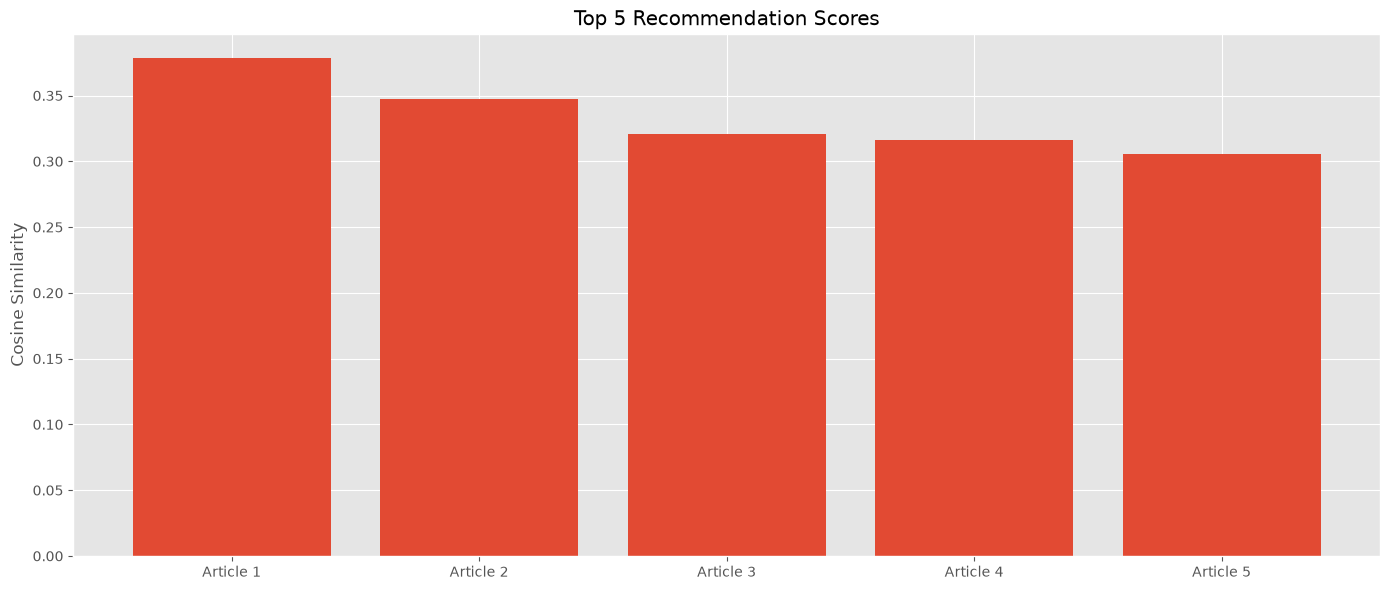

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    recommendations["headline"],
    recommendations["similarity_score"]
)

plt.xticks(
    range(len(recommendations)),
    [f"Article {i+1}" for i in range(len(recommendations))]
)

plt.ylabel("Cosine Similarity")

plt.title("Top 5 Recommendation Scores")

plt.tight_layout()

plt.show()

In [78]:
for i, row in recommendations.iterrows():
    print(f"{i}: {row['headline']}")

115339: The $11-Million Manhunt
46053: More Than 10 Million Americans Now Identify As LGBT
1091: CDC Estimates More Than 140 Million Americans Have Had COVID So Far
36153: America’s Health Is In The Hands Of GOP Frat Boys
35272: The Global Cyberattack And The Need To Revisit Health Care Cybersecurity


In [84]:
from src.preprocessing import preprocess_text

In [85]:

sample = "OpenAI Launches GPT-6! Visit https://openai.com"

print(preprocess_text(sample))

openai launch gpt visit


In [86]:
from src.feature_engineering import create_tfidf_matrix

vectorizer, tfidf_matrix = create_tfidf_matrix(df["clean_text"])

print(tfidf_matrix.shape)

(209527, 10000)


In [87]:
from src.recommender import (
    recommend_articles,
    search_articles,
    recommend_articles_by_title
)

In [88]:
recommend_articles_by_title(
    "Apple",
    df,
    tfidf_matrix
)

Selected Article
Uvalde Children Grapple With Trauma After School Massacre
Category: U.S. NEWS

Top Recommendations



,headline,category,clean_text,similarity_score
86375,Many Kids With Mental Health Issues See Only P...,HEALTHY LIVING,many kid mental health issue see pediatrician ...,0.414149
14268,Trump Suggests Florida Students Could Have Don...,POLITICS,trump suggests florida student could done prev...,0.375853
178200,Do We Really Care About the Mental Health of O...,PARENTING,really care mental health teen need start move...,0.364471
176585,Mass Murder: Is There a Mental Health Issue?,WELLNESS,mass murder mental health issue anything done ...,0.358343
92073,Charles Haley's Hall Of Fame Speech Was The Mo...,SPORTS,charles haley hall fame speech moment needed m...,0.351559


In [89]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/clean_articles.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [90]:
print(df["clean_text"].isna().sum())

0


In [91]:
df.to_csv(
    "../data/processed/clean_articles.csv",
    index=False
)

print("Updated dataset saved!")

Updated dataset saved!


In [92]:
saved_df = pd.read_csv("../data/processed/clean_articles.csv")

print(saved_df["clean_text"].isna().sum())
print(saved_df.shape)

15
(209527, 9)
